### DSMPC without Terminal Ingredients HALL AND ERDIN

Copyright (C) 2024, Alexander Erdin (aerdin@ethz.ch), ETH Zurich

This project is licensed under the MIT License.

#### Setup

In [1]:
# Reload scripts when executed
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from time import sleep
from tqdm.notebook import trange
import matplotlib.pyplot as plt
from params import DSMPCParams
from systems import LinearSystem
from controllers import EMPC

In [3]:
# Fix random seed
np.random.seed(1)
np.set_printoptions(threshold=10000, linewidth=np.inf)

##### Load parameters and create system

In [4]:
params = DSMPCParams()
sys = LinearSystem(params.sys)

In [ ]:
import casadi

# Define optimization variables
prob = casadi.Opti()
x = prob.variable(params.sys.n, 1)
u = prob.variable(params.sys.m, 1)
t = prob.parameter(1)

# x = np.ones((params.n*params.M, 1))
# u = np.ones((params.m*params.M, 1))
# t = 1

tmp = params.ctrl.stage_cost(x, u, t)
tmp

In [158]:
test_x = params.ctrl.h_x(x[0,0,:], 0)
print(test_x)
if all(test_x <= 0):
    print("Feasible")

test_u = params.ctrl.h_u(u[0,0,:], 0)
print(test_u)
if all(test_u <= 0):
    print("Feasible")

[-1000. -1000. -1000. -1000. -1000. -1000. -1000. -1000. -1000. -1000.
 -1000. -1000. -1000. -1000. -1000. -1000. -1000. -1000. -1000. -1000.]
Feasible
[ -9999.49999998 -10000.00700003  -9999.49997424 -10000.00002577
  -9999.49999993 -10000.00280008  -9999.49997424 -10000.00002577
  -9999.49997424 -10000.00002577  -9999.49997424 -10000.00002577
  -9999.49999996 -10000.00420005  -9999.49999985 -10000.00140016
  -9999.49999996 -10000.00420005  -9999.49859983 -10000.00000018]
Feasible


##### Initialize controller

In [5]:
ctrl = EMPC(sys, params.ctrl)

### Simulate System

In [6]:
# Setup simulation
num_steps = params.sim.num_steps
num_traj = params.sim.num_traj
x_0 = params.sim.x_0

# Allocate state and input trajectories
x = np.zeros((num_traj, num_steps+1, sys.n))
u = np.zeros((num_traj, num_steps,   sys.m))

# Simulate closed-loop system
x[:,0,:] = x_0
for i in trange(num_traj, desc='Trajectories'):
    for t in trange(num_steps, desc='MPC', leave=False):
        sol_u, sol_x, error_msg = ctrl.solve(x[i,t,:], additional_parameters=t, verbose=False)
        if error_msg != None:
            raise Exception(error_msg)
        u[i,t,:]   = sol_u[:,0]
        x[i,t+1,:] = sol_x[:,1]
        sleep(0.01)

Trajectories:   0%|          | 0/1 [00:00<?, ?it/s]

MPC:   0%|          | 0/48 [00:00<?, ?it/s]

##### Plot result

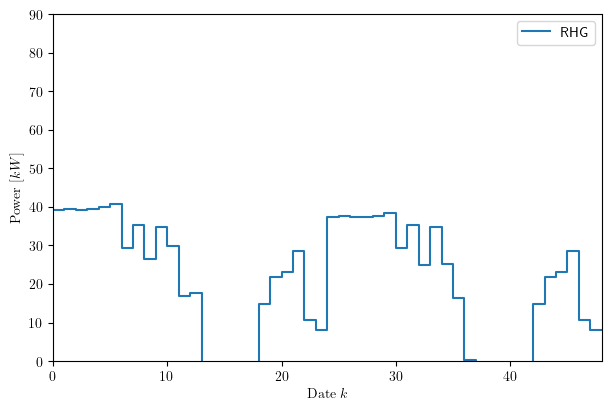

In [7]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create time vector
t = np.arange(num_steps+1)

# Compute aggregate load
agg_load = [np.hstack([u[i,t,:] @ np.ones((params.sys.m, 1)) - params.ctrl.solar[t%24,:].sum() + params.ctrl.passive_load[t%24] for t in range(num_steps)]) for i in range(num_traj)]
agg_load = [np.hstack([agg_load[t], agg_load[t][-1]]) for t in range(num_traj)]

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot trajectories
for i in range(num_traj):
    axs.plot(t, agg_load[i], label='RHG' if i == 0 else '_', color='tab:blue', linestyle='-', drawstyle='steps-post')

# Add labels
axs.set_xlabel(r'\rmfamily{Date} $k$')
axs.set_ylabel(r'\rmfamily{Power} $[kW]$')

# Set limits
axs.set_xlim([0, t.max()])
axs.set_ylim([0, 90])

# Plot legend
axs.legend(loc='upper right')

# Export figure
# fig.savefig("figures/figure_gruene.svg")

In [69]:
import casadi
import numpy as np

# Create constraint vector
A = np.array([[[1], [-1]], [[.5], [-.5]]])
b = np.array([[2], [-1]])

# Define optimization variables
prob = casadi.Opti()
x = prob.variable()
t = prob.parameter()
#t_mod = casadi.fmod(t, 3)

# Compute one-hot encoding for A
A_enc = np.zeros(A.shape[1::])
for i in range(A.shape[0]):
    A_enc += casadi.if_else(t == i, A[i,::], 0)

# Define the optimization problem
prob.minimize(x**2)
prob.subject_to(A_enc @ x <= b)

prob.solver('ipopt')

In [70]:
# Set value of t
prob.set_value(t, 0)

# Solve the optimization problem
sol = prob.solve()
print(sol.value(x))

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.7.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        2
Number of nonzeros in Lagrangian Hessian.............:        1

Total number of variables............................:        1
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        2
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        2

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 1.00e+00 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [21]:
N = 2
M = 2
T = 24

rho_1 = 1/M * np.ones((T, M))
rho_1[[6,7,8,18,19,20,21]] *= 2
print(rho_1)

[[0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [1.  1. ]
 [1.  1. ]
 [1.  1. ]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [1.  1. ]
 [1.  1. ]
 [1.  1. ]
 [1.  1. ]
 [0.5 0.5]
 [0.5 0.5]]


In [28]:
import pandas as pd

# Load processed data
data = pd.read_csv('./params/processed_data_newyork.csv', engine='python',
                    encoding="ISO-8859-1", header = [0, 1], index_col=0)

# Convert index to datetime
data.index = pd.to_datetime(data.index, utc=False)

In [54]:
# Define data

battery1                 ... consumption                      
dataid                          27  142  387  950  ...        5587   5679   5997    9053
hours                                              ...                                  
2019-05-01 01:00:00-04:00      0.0  0.0  0.0  0.0  ...       1.573  1.052  1.303   3.133
2019-05-01 02:00:00-04:00      0.0  0.0  0.0  0.0  ...       1.523  0.709  1.601   3.385
2019-05-01 03:00:00-04:00      0.0  0.0  0.0  0.0  ...       5.947  1.095  1.777   1.952
2019-05-01 04:00:00-04:00      0.0  0.0  0.0  0.0  ...       3.505  1.596  1.559   1.744
2019-05-01 05:00:00-04:00      0.0  0.0  0.0  0.0  ...       6.554  2.855  6.203   0.917
...                            ...  ...  ...  ...  ...         ...    ...    ...     ...
2019-10-31 20:00:00-04:00      0.0  0.0  0.0  0.0  ...       1.863  5.011  3.196  19.437
2019-10-31 21:00:00-04:00      0.0  0.0  0.0  0.0  ...       2.316  3.732  2.593  19.401
2019-10-31 22:00:00-04:00      0.0  0.0  0.0  0.0  ...       1.992  3.602  4.658  17.534
2019-10-31 23:00:00-04:00      0.0  0.0  0.0  0.0  ...       1.712  2.931  4.174   3.900
2019-11-01 00:00:00-04:00      0.0  0.0  0.0  0.0  ...       1.583  2.972  2.361   3.205

[4416 rows x 84 columns]

In [77]:
# Define start and end date
start_date = pd.Timestamp('2019-05-02 00:00:00', tz= 'US/Eastern')
end_date = start_date + pd.Timedelta(hours = N)

# Get agent ids
agent_ids = [agent for agent in data.columns.levels[1] if agent not in ['950', '1240', '27']]

# Remove agents from list
#agent_ids = [agent_id for agent_id in agent_ids if agent_id not in ['950', '1240', '27']]
agent_ids

['1222',
 '1417',
 '142',
 '2096',
 '2318',
 '2358',
 '3000',
 '3488',
 '3517',
 '3700',
 '387',
 '3996',
 '4550',
 '5058',
 '5587',
 '5679',
 '5997',
 '9053']

In [88]:
data = data.loc[start_date:end_date, :]

# Get all agent ids, excluding those in remove_agents
agent_ids = [agent for agent in data.columns.levels[1] if agent not in ['950', '1240', '27']]

# Select the first `num_agents` from agent_ids
selected_agents = agent_ids[:5]

# Filter data for the date range and selected agents
filtered_data = data.loc[:, pd.IndexSlice[:, selected_agents]]

# Get consumption data
consumption = filtered_data.consumption.to_numpy()

# Compute passive load
passive_load = consumption[:-1, 0:2].sum(axis=1)

# Get solar data
solar = 0.35 * filtered_data.all_solar[:-1].to_numpy()

In [98]:
filtered_data.all_solar[:]

dataid,1222,1417,142,2096,2318
hours,,,,,
2019-05-02 00:00:00-04:00,-0.02,0.0,-0.008,0.0,0.0
2019-05-02 01:00:00-04:00,-0.02,0.0,-0.008,0.0,0.0
2019-05-02 02:00:00-04:00,-0.02,0.0,-0.008,0.0,0.0
